In [ ]:
!pip install gymnasium[classic-control] -q

import gymnasium as gym
print(gym.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 153.9 MB/s eta 0:00:00
1.3.0


In [ ]:
env = gym.make("CartPole-v1")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

obs, info = env.reset(seed=42)
print("Initial observation:", obs)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


In [ ]:
obs, info = env.reset(seed=42)
total_reward = 0
steps = 0

while True:
    action = env.action_space.sample()  # random policy
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1
    if terminated or truncated:
        break

print(f"Steps: {steps}, Total reward: {total_reward}")
env.close()

Steps: 29, Total reward: 29.0


In [ ]:
import numpy as np

env = gym.make("CartPole-v1")
rewards = []

for ep in range(100):
    obs, info = env.reset(seed=ep)
    total_reward = 0
    while True:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break
    rewards.append(total_reward)

env.close()

rewards = np.array(rewards)
print(f"Random baseline over 100 episodes")
print(f"Mean: {rewards.mean():.2f}")
print(f"Std:  {rewards.std():.2f}")
print(f"Min:  {rewards.min():.0f}  Max: {rewards.max():.0f}")

Random baseline over 100 episodes
Mean: 21.56
Std:  10.43
Min:  9  Max: 77


In [ ]:
!pip install imageio -q

import imageio

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, info = env.reset(seed=42)
frames = []

while True:
    frames.append(env.render())
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break

env.close()
imageio.mimsave("random_agent.gif", frames, fps=30)
print(f"Saved {len(frames)} frames")

Saved 20 frames


In [ ]:
imageio.mimsave("random_agent.gif", frames, fps=5)  # 30 yerine 5 — 6 kat daha yavaş

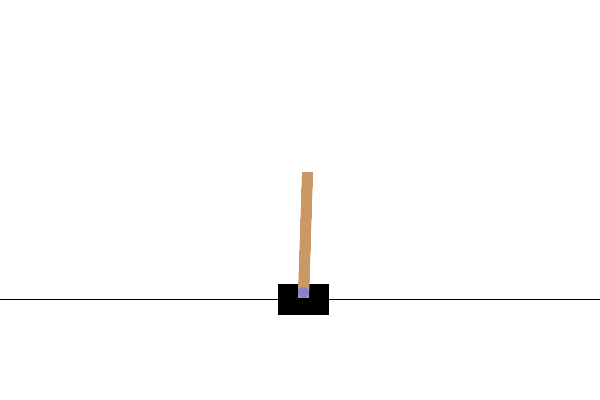

In [ ]:
from IPython.display import Image
Image(open("random_agent.gif", "rb").read())

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# Hyperparameters
ENV_NAME = "CartPole-v1"
GAMMA = 0.99              # discount factor for future rewards
LEARNING_RATE = 1e-3
BUFFER_SIZE = 10000        # replay buffer capacity
BATCH_SIZE = 64
EPSILON_START = 1.0        # start fully random
EPSILON_END = 0.05         # keep a little exploration even late
EPSILON_DECAY = 0.995      # multiply epsilon by this every episode
TARGET_UPDATE_FREQ = 10    # sync target network every N episodes
NUM_EPISODES = 300

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class QNetwork(nn.Module):
    """
    Maps an observation (4 numbers) to a Q-value for each action (2 numbers).
    Simple fully-connected network, no need for anything fancy here.
    """
    def __init__(self, obs_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

Using device: cuda


In [ ]:
import gymnasium as gym

env = gym.make(ENV_NAME)
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print(f"Observation dim: {obs_dim}, Action dim: {action_dim}")

q_net = QNetwork(obs_dim, action_dim).to(device)
print(q_net)

# sanity check: feed one observation, see if it outputs 2 Q-values
obs, info = env.reset(seed=0)
obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
q_values = q_net(obs_tensor)
print(f"Q-values for initial state: {q_values}")

env.close()

Observation dim: 4, Action dim: 2
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Q-values for initial state: tensor([[-0.0364, -0.1469]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [ ]:
class ReplayBuffer:
    """
    Stores past experiences as (observation, action, reward, next_observation, done) tuples.
    We sample random batches from here instead of training on consecutive steps,
    because consecutive steps are highly correlated and would destabilize training.
    """
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(obs)).to(device),
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.FloatTensor(np.array(next_obs)).to(device),
            torch.FloatTensor(dones).to(device)
        )

    def __len__(self):
        return len(self.buffer)

In [ ]:
import numpy as np

buffer = ReplayBuffer(BUFFER_SIZE)

# fill it with a few fake random-agent experiences
env = gym.make(ENV_NAME)
obs, info = env.reset(seed=0)

for _ in range(200):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    buffer.push(obs, action, reward, next_obs, done)
    obs = next_obs
    if done:
        obs, info = env.reset()

env.close()

print(f"Buffer size: {len(buffer)}")

# sanity check: sample a batch
obs_batch, action_batch, reward_batch, next_obs_batch, done_batch = buffer.sample(BATCH_SIZE)
print(f"obs_batch shape: {obs_batch.shape}")
print(f"action_batch shape: {action_batch.shape}")
print(f"reward_batch shape: {reward_batch.shape}")
print(f"next_obs_batch shape: {next_obs_batch.shape}")
print(f"done_batch shape: {done_batch.shape}")

Buffer size: 200
obs_batch shape: torch.Size([64, 4])
action_batch shape: torch.Size([64])
reward_batch shape: torch.Size([64])
next_obs_batch shape: torch.Size([64, 4])
done_batch shape: torch.Size([64])


In [ ]:
# Two networks: one we actively train, one that stays "frozen" for stability
policy_net = QNetwork(obs_dim, action_dim).to(device)
target_net = QNetwork(obs_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())  # copy weights
target_net.eval()  # target network is never trained directly

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
buffer = ReplayBuffer(BUFFER_SIZE)


def select_action(obs, epsilon):
    """
    Epsilon-greedy: with probability epsilon, act randomly (explore).
    Otherwise, pick the action with the highest Q-value (exploit).
    """
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = policy_net(obs_tensor)
        return q_values.argmax().item()

In [ ]:
env = gym.make(ENV_NAME)
obs, info = env.reset(seed=0)

# with epsilon=1.0, should always be random
actions_random = [select_action(obs, epsilon=1.0) for _ in range(20)]
print(f"Epsilon=1.0 actions: {actions_random}")

# with epsilon=0.0, should always pick the same action (greedy, untrained network)
actions_greedy = [select_action(obs, epsilon=0.0) for _ in range(20)]
print(f"Epsilon=0.0 actions: {actions_greedy}")

env.close()

Epsilon=1.0 actions: [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
Epsilon=0.0 actions: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
def compute_loss():
    if len(buffer) < BATCH_SIZE:
        return None  # not enough experiences yet, skip training

    obs_batch, action_batch, reward_batch, next_obs_batch, done_batch = buffer.sample(BATCH_SIZE)

    # Step 1: what Q-value did policy_net predict for the action we actually took?
    q_values = policy_net(obs_batch)                              # shape (64, 2)
    q_taken = q_values.gather(1, action_batch.unsqueeze(1)).squeeze(1)  # shape (64,)

    # Step 2: what's the best possible Q-value in the NEXT state, according to target_net?
    with torch.no_grad():
        next_q_values = target_net(next_obs_batch)                # shape (64, 2)
        next_q_max = next_q_values.max(1)[0]                      # shape (64,)
        # if done, there is no future -> target is just the reward
        target = reward_batch + GAMMA * next_q_max * (1 - done_batch)

    # Step 3: how far off was our prediction from the target?
    loss = nn.functional.mse_loss(q_taken, target)
    return loss

In [ ]:
loss = compute_loss()
print(f"Loss (buffer too small, should be None): {loss}")

# fill buffer more to pass the BATCH_SIZE threshold
env = gym.make(ENV_NAME)
obs, info = env.reset(seed=0)
for _ in range(100):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    buffer.push(obs, action, reward, next_obs, done)
    obs = next_obs
    if done:
        obs, info = env.reset()
env.close()

print(f"Buffer size now: {len(buffer)}")
loss = compute_loss()
print(f"Loss: {loss.item():.4f}")

Loss (buffer too small, should be None): None
Buffer size now: 100
Loss: 1.0232


In [ ]:
def train_step():
    """One gradient update using compute_loss()."""
    loss = compute_loss()
    if loss is None:
        return None

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()


def train_dqn():
    env = gym.make(ENV_NAME)
    epsilon = EPSILON_START
    episode_rewards = []

    for episode in range(NUM_EPISODES):
        obs, info = env.reset(seed=episode)
        total_reward = 0
        done = False

        while not done:
            action = select_action(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            buffer.push(obs, action, reward, next_obs, done)
            obs = next_obs
            total_reward += reward

            train_step()  # train on every single environment step

        episode_rewards.append(total_reward)
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # sync target network periodically
        if episode % TARGET_UPDATE_FREQ == 0:
            target_net.load_state_dict(policy_net.state_dict())

        # print progress every 20 episodes
        if (episode + 1) % 20 == 0:
            avg_last_20 = np.mean(episode_rewards[-20:])
            print(f"Episode {episode+1}/{NUM_EPISODES} | "
                  f"Avg reward (last 20): {avg_last_20:.1f} | "
                  f"Epsilon: {epsilon:.3f}")

    env.close()
    return episode_rewards

In [ ]:
episode_rewards = train_dqn()

Episode 20/300 | Avg reward (last 20): 29.7 | Epsilon: 0.905
Episode 40/300 | Avg reward (last 20): 18.4 | Epsilon: 0.818
Episode 60/300 | Avg reward (last 20): 19.4 | Epsilon: 0.740
Episode 80/300 | Avg reward (last 20): 32.1 | Epsilon: 0.670
Episode 100/300 | Avg reward (last 20): 61.0 | Epsilon: 0.606
Episode 120/300 | Avg reward (last 20): 80.0 | Epsilon: 0.548
Episode 140/300 | Avg reward (last 20): 95.5 | Epsilon: 0.496
Episode 160/300 | Avg reward (last 20): 59.2 | Epsilon: 0.448
Episode 180/300 | Avg reward (last 20): 79.2 | Epsilon: 0.406
Episode 200/300 | Avg reward (last 20): 82.3 | Epsilon: 0.367
Episode 220/300 | Avg reward (last 20): 54.6 | Epsilon: 0.332
Episode 240/300 | Avg reward (last 20): 47.5 | Epsilon: 0.300
Episode 260/300 | Avg reward (last 20): 108.2 | Epsilon: 0.272
Episode 280/300 | Avg reward (last 20): 102.7 | Epsilon: 0.246
Episode 300/300 | Avg reward (last 20): 109.7 | Epsilon: 0.222


In [ ]:
import imageio

env = gym.make(ENV_NAME, render_mode="rgb_array")
obs, info = env.reset(seed=42)  # same seed as random_agent.gif, fair comparison
frames = []

policy_net.eval()
with torch.no_grad():
    while True:
        frames.append(env.render())
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
        action = policy_net(obs_tensor).argmax().item()  # pure greedy, epsilon=0
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            break

env.close()
policy_net.train()

print(f"Trained agent survived {len(frames)} steps (random agent survived 17-23 steps)")
imageio.mimsave("trained_dqn_agent.gif", frames, fps=15)

Trained agent survived 252 steps (random agent survived 17-23 steps)


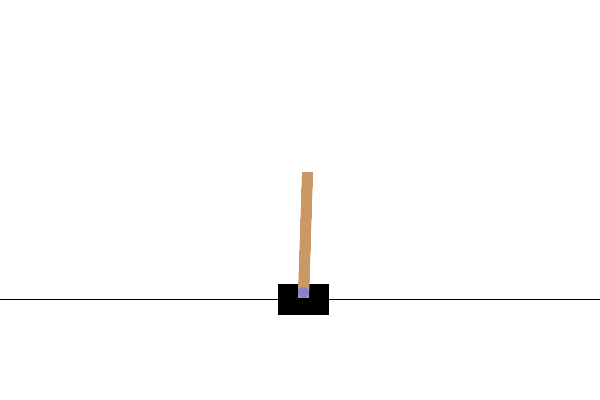

In [ ]:
from IPython.display import Image
Image(open("trained_dqn_agent.gif", "rb").read())

In [ ]:
torch.save(policy_net.state_dict(), "dqn_cartpole.pth")
print("DQN model saved.")

DQN model saved.
